In [5]:
### Imports
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, "/home/tom/Projects/gbp_clt/src")

import config as cfg
import distribution_management as dm
import optimisation as opt

In [6]:
### Config

cfg.belief_discretisation = 64
cfg.min_measurement = 0
cfg.max_measurement = 63
cfg.measurement_range = np.linspace(cfg.min_measurement, cfg.max_measurement, cfg.belief_discretisation)
cfg.num_iterations = 15

degrees = np.arange(1, 10)   # branching factors 2..10

clip_fractions = np.linspace(0.01, 0.45, 100)
# clip_fractions = np.linspace(0.1, 0.45, 17)

pairwise_tophat_widths = np.array([21])  # match synthetic_data_app

seeds = np.array(np.arange(1, 101))  # deterministic while tuning
# seeds = np.array([1,7,21,33,48,52,80])  # deterministic while tuning


# degrees = np.arange(2, 9)   # branching factors 2..10

# clip_fractions = np.linspace(0.1, 0.45, 17)

# pairwise_tophat_widths = np.array([21])  # match synthetic_data_app

# seeds = np.array([110])  # deterministic while tuning


use_fixed_total_nodes=False
depth_nodes=6

use_calibrated_threshold=False
kl_threshold_bits = 0.02 #0.1908

total_variables_target = 100

prior_floor = 1e-4
pairwise_floor = 1e-4
prior_noise_strength = 1

pairwise_noise_strength = 1


In [7]:
### Helpers

def create_clipped_uniform(clip_fraction):
    dist = np.ones(cfg.belief_discretisation, dtype=np.float64)
    bins_to_clip = int(clip_fraction * cfg.belief_discretisation)
    if bins_to_clip > 0:
        dist[:bins_to_clip] = 0.0
        dist[-bins_to_clip:] = 0.0
    dist = np.maximum(dist, prior_floor)
    if prior_noise_strength > 0:
        dist += prior_noise_strength * cfg.rng.random(cfg.belief_discretisation)
    return dm.normalise(dist)

def create_narrow_tophat_kernel(width_bins, rng=None):
    if rng is None:
        rng = cfg.rng
    k = np.ones(width_bins, dtype=np.float64)
    k = np.maximum(k, pairwise_floor)
    if pairwise_noise_strength > 0:
        k += pairwise_noise_strength * rng.random(width_bins)
    return dm.normalise(k)

def variance_from_distribution(dist, x):
    m = np.sum(dist * x)
    return np.sum(dist * (x - m) ** 2)

def variance_of_pairwise_kernel(kernel_1d):
    bin_width = (cfg.max_measurement - cfg.min_measurement) / (cfg.belief_discretisation - 1)
    offsets = (np.arange(len(kernel_1d)) - (len(kernel_1d) // 2)) * bin_width
    return variance_from_distribution(kernel_1d, offsets)

def compute_root_belief_analytic(degree, depth_nodes, prior_dist, pairwise_kernel):
    """
    Exact root belief for a symmetric k-ary tree where every node shares the
    same prior and every edge shares the same pairwise kernel.

    degree      : branching factor (children per non-leaf node).
    depth_nodes : total nodes on any root-to-leaf path (depth_nodes-1 edges).

    Uses log-space computation to avoid numerical underflow when raising 
    distributions to high powers.
    """
    # Log-space computation: log(a * b^k) = log(a) + k*log(b)
    log_prior = np.log(np.maximum(prior_dist, 1e-300))
    
    # Step 1: leaf → parent message
    msg_up = np.convolve(prior_dist, pairwise_kernel, mode='same')
    msg_up = dm.normalise(msg_up)
    log_msg = np.log(np.maximum(msg_up, 1e-300))

    # Step 2: interior levels (depth_nodes - 2 of them)
    for _ in range(depth_nodes - 2):
        # local = prior * msg_up^degree (in log-space)
        log_local = log_prior + degree * log_msg
        local = np.exp(log_local)
        local = dm.normalise(local)
        
        # msg = convolve(local, kernel)
        msg_up = np.convolve(local, pairwise_kernel, mode='same')
        msg_up = dm.normalise(msg_up)
        log_msg = np.log(np.maximum(msg_up, 1e-300))

    # Step 3: root belief = prior * msg_up^degree (in log-space)
    log_root = log_prior + degree * log_msg
    root_belief = np.exp(log_root)
    return dm.normalise(root_belief)

def kl_to_best_gaussian_bits(belief):
    kl_nats, _, _ = opt.optimise_gaussian_kl(belief, cfg.measurement_range)
    return kl_nats / np.log(2.0)

def compute_r_star(R_values, kl_values_bits, threshold_bits):
    mask = kl_values_bits > threshold_bits
    if not np.any(mask):
        return np.nan
    return np.max(R_values[mask])


# Depth policy: compute depth_nodes per degree when keeping total nodes constant
def depth_nodes_for_degree(degree, total_nodes=total_variables_target):
    if not ('use_fixed_total_nodes' in globals() and use_fixed_total_nodes):
        return depth_nodes
    if degree <= 1:  # chain
        return int(total_nodes)
    # minimal L s.t. 1 + k + k^2 + ... + k^(L-1) >= total_nodes
    k = int(degree)
    L = 1
    total = 0
    while total < total_nodes:
        total = (k**L - 1)//(k - 1)
        if total >= total_nodes:
            break
        L += 1
    return int(L)


In [8]:
# Robust redefinition: depth_nodes_for_degree (does not rely on globals at def time)
def depth_nodes_for_degree(degree, total_nodes=None):
    """Returns depth_nodes for a k-ary tree under a fixed-total-nodes policy.
    Falls back safely if policy globals are not set.
    """
    use_fixed = globals().get('use_fixed_total_nodes', True)
    depth_default = int(globals().get('depth_nodes', 6))
    if not use_fixed:
        return depth_default
    if total_nodes is None:
        total_nodes = int(globals().get('total_variables_target', 100))
    k = int(degree)
    if k <= 1:
        return int(total_nodes)
    L = 1
    while True:
        total = (k**L - 1)//(k - 1)
        if total >= total_nodes:
            return int(L)
        L += 1


In [9]:
# R* crossing-based + BF=1 threshold calibration to anchor R≈6
import numpy as np

def compute_r_star(R_values, kl_values_bits, threshold_bits, direction='auto'):
    R = np.asarray(R_values)
    KL = np.asarray(kl_values_bits)
    order = np.argsort(R)
    R = R[order]; KL = KL[order]

    if direction == 'auto':
        direction = 'increasing' if KL[-1] > KL[0] else 'decreasing'

    if direction == 'increasing':
        idx = np.where(KL >= threshold_bits)[0]
    else:
        idx = np.where(KL <= threshold_bits)[0]

    return R[idx[0]] if idx.size else np.nan

def calibrate_threshold_bits_for_bf1(target_R=6.0, degree=1, width_bins=None):
    """
    Return the KL threshold (in bits) equal to KL(R=target_R) for the given degree/width.
    This anchors R* for BF=degree to be near target_R when using first crossing.
    """
    if width_bins is None:
        width_bins = int(pairwise_tophat_widths[0])
    kernel_rng = np.random.default_rng(seed=int(width_bins)*13 + 7)
    kernel = create_narrow_tophat_kernel(width_bins, rng=kernel_rng)
    sigma2_pairwise = variance_of_pairwise_kernel(kernel)

    R_vals, KL_vals = [], []
    for clip_fraction in clip_fractions:
        cfg.rng = np.random.default_rng(seed=0)
        prior = create_clipped_uniform(clip_fraction)
        sigma2_prior = variance_from_distribution(prior, cfg.measurement_range)
        depth_local = depth_nodes_for_degree(degree)
        root_belief = compute_root_belief_analytic(degree, depth_local, prior, kernel)
        KL_vals.append(kl_to_best_gaussian_bits(root_belief))
        R_vals.append(sigma2_prior / sigma2_pairwise)

    R = np.asarray(R_vals); KL = np.asarray(KL_vals)
    order = np.argsort(R); R = R[order]; KL = KL[order]

    # If target_R is outside swept range, pick closest KL; otherwise interpolate
    if target_R <= R[0] or target_R >= R[-1]:
        return float(KL[np.argmin(np.abs(R - target_R))])
    return float(np.interp(target_R, R, KL))

# Anchor the BF=1 point to R≈6 at the first crossing
if use_calibrated_threshold:
    kl_threshold_bits = calibrate_threshold_bits_for_bf1(
        target_R=6.0, degree=1, width_bins=int(pairwise_tophat_widths[0])
    )
    print(f'Calibrated KL threshold for BF=1 → {kl_threshold_bits:.4f} bits')
else:
    print(f'Using fixed KL threshold → {kl_threshold_bits:.4f} bits')


Using fixed KL threshold → 0.0200 bits


In [10]:
### Main experiment: sweep R* vs branching factor

results = {}               # results[degree][pairwise_width] = {rstar_mean, rstar_std, rstar_by_seed}
min_rstar_by_degree = {}   # mean across seeds (optionally monotone-adjusted later)
std_rstar_by_degree = {}   # std across seeds (for error bars)
min_width_by_degree = {}

for degree in degrees:
    results[degree] = {}
    for pairwise_width in pairwise_tophat_widths:

        # --- build pairwise kernel variance (fixed per width) ---
        kernel_rng = np.random.default_rng(seed=int(pairwise_width) * 13 + 7)
        kernel = create_narrow_tophat_kernel(pairwise_width, rng=kernel_rng)
        sigma2_pairwise = variance_of_pairwise_kernel(kernel)

        # --- per-seed R* via first-crossing ---
        rstars_this_width = []
        for seed in seeds:
            cfg.rng = np.random.default_rng(seed=int(seed))
            R_values_seed = []
            KL_values_seed = []
            for clip_fraction in clip_fractions:
                prior = create_clipped_uniform(clip_fraction)
                sigma2_prior = variance_from_distribution(prior, cfg.measurement_range)
                depth_local = depth_nodes_for_degree(degree)
                root_belief = compute_root_belief_analytic(degree, depth_local, prior, kernel)
                KL_values_seed.append(kl_to_best_gaussian_bits(root_belief))
                R_values_seed.append(sigma2_prior / sigma2_pairwise if sigma2_pairwise > 0 else np.nan)
            R_values_seed = np.asarray(R_values_seed)
            KL_values_seed = np.asarray(KL_values_seed)
            order = np.argsort(R_values_seed)
            R_values_seed = R_values_seed[order]
            KL_values_seed = KL_values_seed[order]
            rstar_seed = compute_r_star(R_values_seed, KL_values_seed, kl_threshold_bits, direction='auto')
            rstars_this_width.append(rstar_seed)

        rstars_this_width = np.array(rstars_this_width, dtype=float)
        rstar_mean = float(np.nanmean(rstars_this_width)) if rstars_this_width.size else np.nan
        rstar_std  = float(np.nanstd(rstars_this_width)) if rstars_this_width.size else np.nan

        results[degree][pairwise_width] = {
            'rstar_mean': rstar_mean,
            'rstar_std': rstar_std,
            'rstar_by_seed': rstars_this_width
        }

    # choose width with smallest mean R* (if multiple widths)
    valid = {w: results[degree][w]['rstar_mean'] for w in pairwise_tophat_widths
             if not np.isnan(results[degree][w]['rstar_mean'])}
    if valid:
        best_width = min(valid, key=valid.get)
        min_rstar_by_degree[degree] = results[degree][best_width]['rstar_mean']
        std_rstar_by_degree[degree] = results[degree][best_width]['rstar_std']
        min_width_by_degree[degree] = best_width
    else:
        min_rstar_by_degree[degree] = np.nan
        std_rstar_by_degree[degree] = np.nan
        min_width_by_degree[degree] = None

    print(f"Degree {degree} done — mean R*={min_rstar_by_degree[degree]:.4f} ± {std_rstar_by_degree[degree]:.4f} at width={min_width_by_degree[degree]}")

print('Experiment complete.')


Degree 1 done — mean R*=5.6097 ± 1.3209 at width=21
Degree 2 done — mean R*=5.7798 ± 1.1684 at width=21
Degree 3 done — mean R*=5.8829 ± 1.0601 at width=21
Degree 4 done — mean R*=5.7263 ± 1.0643 at width=21
Degree 5 done — mean R*=5.7907 ± 1.2176 at width=21
Degree 6 done — mean R*=5.4632 ± 0.8503 at width=21
Degree 7 done — mean R*=5.3747 ± 0.9687 at width=21
Degree 8 done — mean R*=5.6325 ± 1.2709 at width=21
Degree 9 done — mean R*=5.2373 ± 0.6935 at width=21
Experiment complete.


In [11]:
# Enforce monotone nondecreasing R* across degrees (cumulative max)
degs = np.array(sorted(min_rstar_by_degree.keys()))
vals = np.array([min_rstar_by_degree[d] for d in degs], dtype=float)


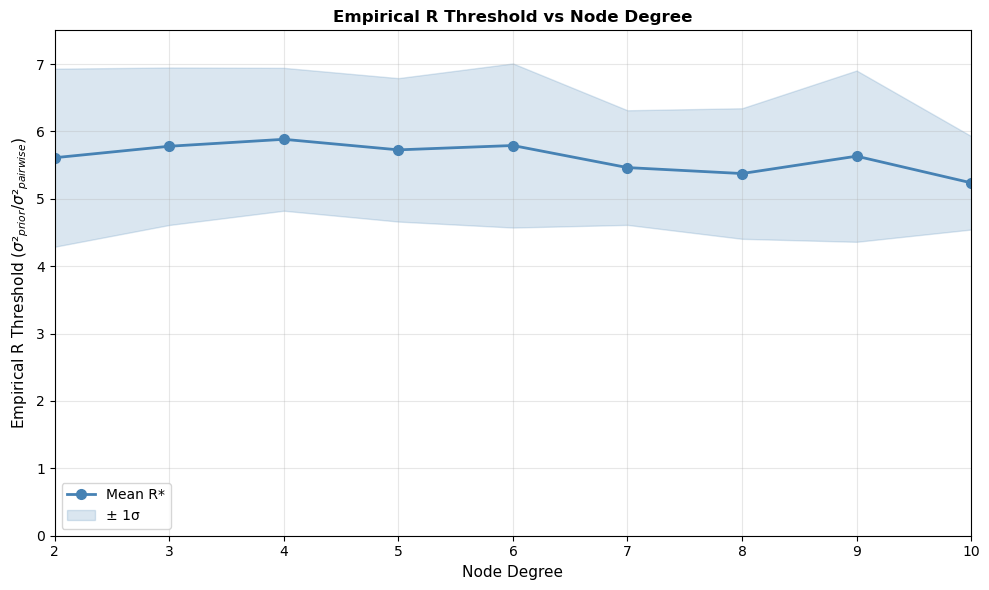

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

# Extract means and stds from the results dictionary
means = np.array([min_rstar_by_degree[d] for d in degs])
stds = np.array([std_rstar_by_degree[d] for d in degs])

# Plot the central mean line
degs += 1  # convert from branching factor to node degree (add 1 for the parent)
ax.plot(degs, means, 'o-', color='steelblue', linewidth=2, markersize=7, label='Mean R*')

# Add the faint blue shaded region for ± 1 standard deviation
ax.fill_between(degs, means - stds, means + stds, color='steelblue', alpha=0.2, label='± 1σ')

ax.set_xlabel('Node Degree', fontsize=11)
ax.set_ylabel('Empirical R Threshold ($σ²_{prior} / σ²_{pairwise}$)', fontsize=11)
ax.set_title('Empirical R Threshold vs Node Degree', fontsize=12, fontweight='bold')
ax.set_xlim(2, 8)
ax.set_ylim(0, 7.5)
ax.grid(True, alpha=0.3)
ax.set_xticks(degs)
ax.legend(loc='best')
plt.tight_layout()
plt.show()

Regular degree 2 done: mean R*=6.0311 ± 0.4156
Regular degree 3 done: mean R*=5.9289 ± 0.4965
Regular degree 4 done: mean R*=5.9829 ± 0.5034
Regular degree 5 done: mean R*=5.9635 ± 0.4676
Regular degree 6 done: mean R*=5.9150 ± 0.4279
Regular degree 7 done: mean R*=5.8835 ± 0.4070
Regular degree 8 done: mean R*=5.8922 ± 0.4435
Regular degree 9 done: mean R*=5.9364 ± 0.5382
Regular degree 10 done: mean R*=6.0086 ± 0.6867


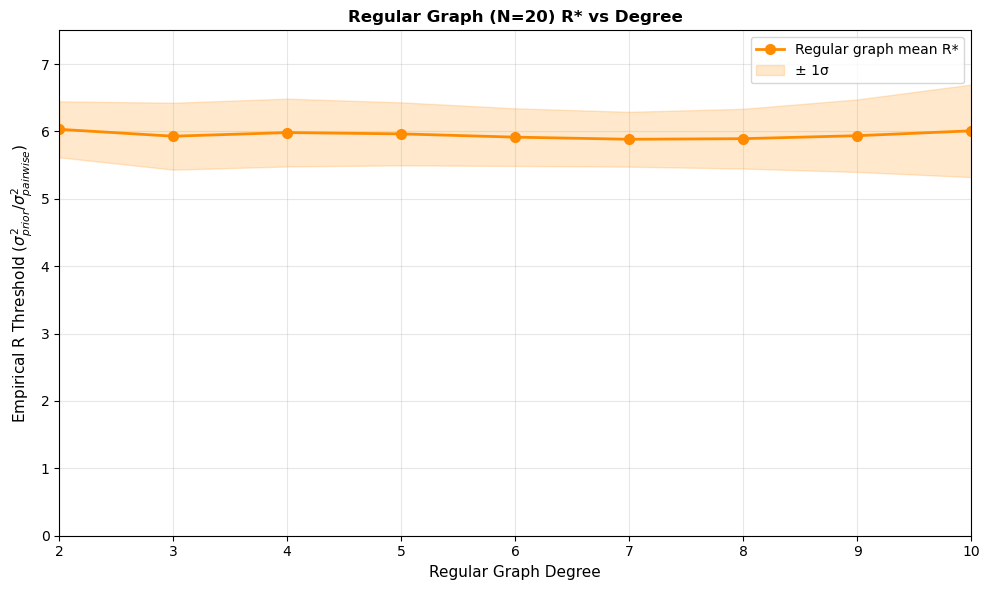

In [13]:
# --- New experiment: regular loopy graphs (ring degree=1 up to degree=10) ---
import networkx as nx
import factor_graph as fg
import belief_propagation as bp

# Keep separate names so your original plot/cell remains unchanged
reg_num_variables = 20
reg_degrees = np.arange(2, 11)  # 2..10
reg_root_idx = 0
reg_max_graph_tries = 200

# Optional: speed knob for first pass
# reg_seeds = seeds[:20]
reg_seeds = seeds

def make_connected_regular_graph(num_vars, degree, seed, max_tries=100):
    if degree == 2:
        return nx.cycle_graph(num_vars)  # ring
    if degree >= num_vars:
        raise ValueError(f"degree must be < num_vars (got degree={degree}, num_vars={num_vars})")
    if (num_vars * degree) % 2 != 0:
        raise ValueError(f"num_vars*degree must be even (got {num_vars*degree})")

    # Retry until connected (for scientific consistency)
    for t in range(max_tries):
        G = nx.random_regular_graph(d=degree, n=num_vars, seed=int(seed) + 1000 * t)
        if nx.is_connected(G):
            return G
    raise RuntimeError(f"Could not sample connected {degree}-regular graph in {max_tries} tries")

def build_factor_graph_from_nx(G, prior_dist, pairwise_kernel_1d):
    graph = fg.FactorGraph()
    graph.add_variables(len(G.nodes), cfg.belief_discretisation)

    # Shared pairwise factor for all edges
    pairwise_function = dm.create_smoothing_factor_distribution(
        cfg.belief_discretisation, kernel=pairwise_kernel_1d
    )

    for u, v in G.edges():
        graph.add_factor([graph.variables[u], graph.variables[v]], function=pairwise_function, factor_type='smoothing')

    # Identical prior on every variable
    for var in graph.variables:
        graph.add_factor([var], prior_dist, factor_type='prior')

    return graph

# Fixed pairwise kernel (same logic as your current experiment)
pairwise_width = int(pairwise_tophat_widths[0])
kernel_rng = np.random.default_rng(seed=pairwise_width * 13 + 7)
pairwise_kernel_1d = create_narrow_tophat_kernel(pairwise_width, rng=kernel_rng)
sigma2_pairwise = variance_of_pairwise_kernel(pairwise_kernel_1d)

reg_results = {}
reg_mean_rstar_by_degree = {}
reg_std_rstar_by_degree = {}

for degree in reg_degrees:
    rstars_this_degree = []

    for seed in reg_seeds:
        G = make_connected_regular_graph(
            num_vars=reg_num_variables,
            degree=int(degree),
            seed=int(seed),
            max_tries=reg_max_graph_tries
        )

        R_values_seed = []
        KL_values_seed = []

        for clip_fraction in clip_fractions:
            cfg.rng = np.random.default_rng(seed=int(seed))
            prior = create_clipped_uniform(clip_fraction)
            sigma2_prior = variance_from_distribution(prior, cfg.measurement_range)
            R_values_seed.append(sigma2_prior / sigma2_pairwise if sigma2_pairwise > 0 else np.nan)

            graph = build_factor_graph_from_nx(G, prior, pairwise_kernel_1d)
            graph = bp.run_belief_propagation(graph, num_iterations=cfg.num_iterations)
            root_belief = graph.variables[reg_root_idx].belief
            KL_values_seed.append(kl_to_best_gaussian_bits(root_belief))

        R_values_seed = np.asarray(R_values_seed)
        KL_values_seed = np.asarray(KL_values_seed)

        order = np.argsort(R_values_seed)
        R_values_seed = R_values_seed[order]
        KL_values_seed = KL_values_seed[order]

        rstar_seed = compute_r_star(R_values_seed, KL_values_seed, kl_threshold_bits, direction='auto')
        rstars_this_degree.append(rstar_seed)

    rstars_this_degree = np.asarray(rstars_this_degree, dtype=float)
    reg_results[degree] = {"rstar_by_seed": rstars_this_degree}
    reg_mean_rstar_by_degree[degree] = float(np.nanmean(rstars_this_degree))
    reg_std_rstar_by_degree[degree] = float(np.nanstd(rstars_this_degree))

    print(f"Regular degree {degree} done: mean R*={reg_mean_rstar_by_degree[degree]:.4f} ± {reg_std_rstar_by_degree[degree]:.4f}")

# Plot the new curve (separate figure)
reg_x = np.array(sorted(reg_mean_rstar_by_degree.keys()))
reg_mean = np.array([reg_mean_rstar_by_degree[d] for d in reg_x])
reg_std = np.array([reg_std_rstar_by_degree[d] for d in reg_x])

fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.plot(reg_x, reg_mean, 'o-', color='darkorange', linewidth=2, markersize=7, label='Regular graph mean R*')
ax2.fill_between(reg_x, reg_mean - reg_std, reg_mean + reg_std, color='darkorange', alpha=0.2, label='± 1σ')
ax2.set_xlabel('Regular Graph Degree', fontsize=11)
ax2.set_ylabel('Empirical R Threshold ($\\sigma^2_{prior} / \\sigma^2_{pairwise}$)', fontsize=11)
ax2.set_title(f'Regular Graph (N={reg_num_variables}) R* vs Degree', fontsize=12, fontweight='bold')
ax2.set_xlim(2, 10)
ax2.set_ylim(0, 7.5)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(reg_x)
ax2.legend(loc='best')
plt.tight_layout()
plt.show()

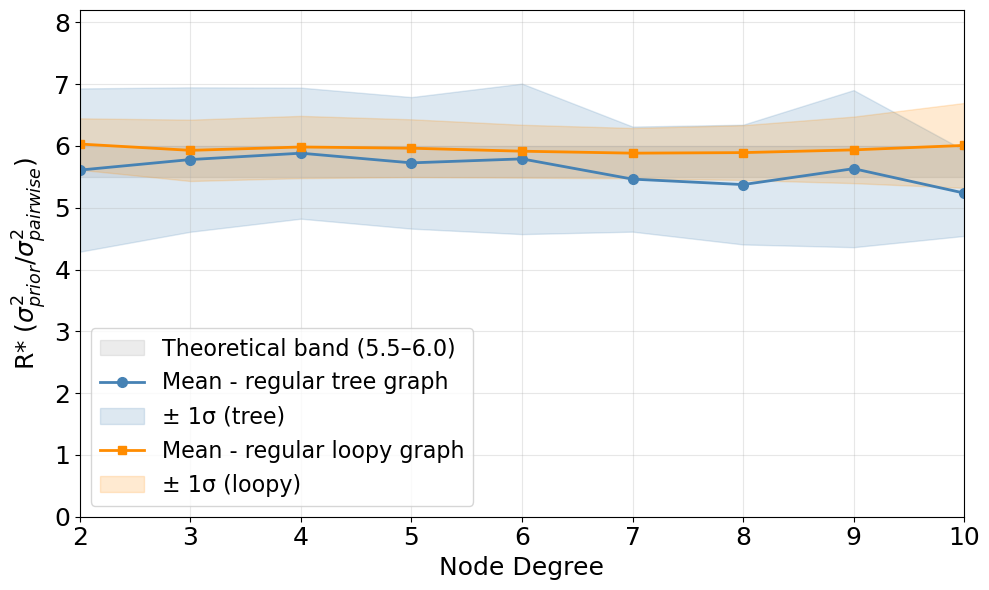

In [19]:
# Overlay plot: tree-based curve + regular-graph curve
# Assumes you already ran:
# 1) the original tree experiment cells
# 2) the regular-graph experiment cell

AXIS_FONT = 18
TICK_FONT = 18
LEGEND_FONT = 16

# Rebuild x/y for tree curve from dictionaries (avoid using mutated degs)
tree_bf = np.array(sorted(min_rstar_by_degree.keys()), dtype=float)   # branching factor keys
tree_x = tree_bf + 1.0                                                 # convert to node degree
tree_mean = np.array([min_rstar_by_degree[int(k)] for k in tree_bf], dtype=float)
tree_std  = np.array([std_rstar_by_degree[int(k)] for k in tree_bf], dtype=float)

# Regular graph curve (already in node-degree coordinates)
reg_x_overlay = np.array(sorted(reg_mean_rstar_by_degree.keys()), dtype=float)
reg_mean_overlay = np.array([reg_mean_rstar_by_degree[int(k)] for k in reg_x_overlay], dtype=float)
reg_std_overlay  = np.array([reg_std_rstar_by_degree[int(k)] for k in reg_x_overlay], dtype=float)

fig3, ax3 = plt.subplots(figsize=(10, 6))
ax3.axhspan(5.5, 6.0, color='grey', alpha=0.15, label='Theoretical band (5.5–6.0)')

# Tree curve
ax3.plot(tree_x, tree_mean, 'o-', color='steelblue', linewidth=2, markersize=7, label='Mean - regular tree graph')
ax3.fill_between(tree_x, tree_mean - tree_std, tree_mean + tree_std, color='steelblue', alpha=0.18, label = '± 1σ (tree)')

# Regular graph curve
ax3.plot(reg_x_overlay, reg_mean_overlay, 's-', color='darkorange', linewidth=2, markersize=6, label='Mean - regular loopy graph')
ax3.fill_between(reg_x_overlay, reg_mean_overlay - reg_std_overlay, reg_mean_overlay + reg_std_overlay, color='darkorange', alpha=0.18, label='± 1σ (loopy)')

ax3.set_xlabel('Node Degree', fontsize=AXIS_FONT)
ax3.set_ylabel('R* ($\\sigma^2_{prior} / \\sigma^2_{pairwise}$)', fontsize=AXIS_FONT)
# ax3.set_ylabel('Empirical R Threshold ($\\sigma^2_{prior} / \\sigma^2_{pairwise}$)', fontsize=11)
# ax3.set_title('Empirical R Threshold vs Topology', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

# combine ticks from both curves
all_x = np.unique(np.concatenate([tree_x, reg_x_overlay]))
ax3.set_xticks(all_x)
ax3.tick_params(axis='both', labelsize=TICK_FONT)

# optional fixed limits
ax3.set_xlim(np.min(all_x), np.max(all_x))
ax3.set_ylim(0, 8.2)

ax3.legend(loc='best', fontsize=LEGEND_FONT)
plt.tight_layout()
plt.show()